# Goals

* leakeage free modeling using 
    * lagged predictors
    * cross-sectional and time-aware

# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

In [3]:
from sklearn.model_selection import train_test_split

In [69]:
from interpret import set_visualize_provider, show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor

set_visualize_provider(InlineProvider())

## Utility functions

In [83]:
seed = 42

In [84]:
def plotting_predictions(ts_true,ts_pred,fig_title):
    plt.figure(figsize=(12,8))
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    
    plt.plot(ts_true,'-bo',label='Actual value')
    plt.plot(ts_pred,'-r^',label='Prediction value')
    
    plt.legend(loc='upper left',fontsize=15)
    plt.title(fig_title,fontsize=18)
    
    #rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    #plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2  : %.2f" % (rmse,mape,r2), \
    #     bbox={'facecolor':'w','pad':5},
    #     ha="right", va="top", transform=plt.gca().transAxes,fontsize=15)
    rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2   : %.2f" % (rmse,mape,r2), \
         bbox={'facecolor':'w','pad':5},
         ha="left", va="top", transform=plt.gca().transAxes,fontsize=15)
    
    plt.show()

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_time_series(y_true, y_pred,verbose=True):
    '''
    Compute the MAE and MSE metrics from sklearn.metrics
    @param y_true: (list) list of the true values
    @param y_pred: (list) list of predicted values
    @return rmse,mape,mae: (float), (float) values of metrics RMSE,MAPE, MAE
    '''
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 2) 
    
    y_true_nz = y_true[(y_true!=0.0)] # non-zero true values (See denom.)
    mape = round(np.mean(np.abs((y_true_nz - y_pred[y_true_nz.index]) / y_true_nz)) * 100,2)
    
    #mae = round(mean_absolute_error(y_true, y_pred),2)
    r2 =  round(r2_score(y_true, y_pred), 2)
    
    if verbose:
        print(f"RMSE : {rmse}")
     #  print(f"MAE : {mae}")
        print(f"MAPE : {mape}")   
        print(f"R2   : {r2}")
    return rmse,mape,r2

# Data Wrangling

In [6]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"

import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
sql = """
select * from wook.fact_amz_mkt_all;
"""
# select zinus_sku_cd as sku, collection from `market-analysis-project-91130.meta.erp_sku_collection_220330`

df = bqclient.query(sql).to_dataframe()
df = df.drop_duplicates()
df

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,yr_wk,rvw_cnt,star12_cnt,star12_ratio
0,B088N8J71Y,Beige Swatch,0.00,24,<NA>,0.000000,4,6.000000,0.000000,FSLTD-BG,None,None,None,202024,<NA>,<NA>,NaN
1,B088NP3K7P,Soft Grey Swatch,0.00,2,<NA>,0.000000,2,1.000000,0.000000,FB5432G,None,None,None,202029,<NA>,<NA>,NaN
2,B07HYVX2NZ,"Zinus Alto Table, White",220.58,1,436,220.580000,39,0.025641,0.000000,OLB-DT-AW47,OLB DT,None,None,202052,<NA>,<NA>,NaN
3,B07GGF5RFF,"Zinus Josh, Sofa, Beige",8331.46,25,72,333.258400,10703,0.002336,0.000000,SSTD-BG,SSTD,None,None,202030,4,2,0.5
4,B07GGF5RFF,"Zinus Josh, Sofa, Beige",25999.62,81,69,320.982963,15518,0.005220,0.000000,SSTD-BG,SSTD,None,None,202029,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174094,B07W8JQ5KR,Zinus Jared 14 Inch Metal Adjustable Bed Frame...,0.00,0,2160,NaN,237,0.000000,0.040486,ADB-14Q,ADB,14 Inch,Queen,202126,<NA>,<NA>,NaN
174095,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,145,NaN,47,0.000000,0.078431,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202144,<NA>,<NA>,NaN
174096,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,5.08,0,363,NaN,277,0.000000,0.051370,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202150,<NA>,<NA>,NaN
174097,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,308,NaN,176,0.000000,0.078534,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202204,<NA>,<NA>,NaN


In [8]:
df.zinus_sku.value_counts()

OLB-SWPB-12T    234
SC-BTCM-8Q      200
SC-SPP-10SQ     165
SC-SMT-8TXL     140
HBPBB-14F       128
               ... 
PFP-T1818AS       3
GOPB-12F          2
UFHCSG-20K        2
PFL-T68G          2
AZ-SBF-T-07F      1
Name: zinus_sku, Length: 1774, dtype: int64

In [9]:
sku_orig = df.zinus_sku.unique()
len(sku_orig)

1775

## datetime handling

In [10]:
df['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df.yr_wk]
df.drop('yr_wk',axis=1,inplace=True)
df.sort_values(by=['year_week','profile'],inplace=True)

In [11]:
df.reset_index(drop=True,inplace=True)

## Range of date

from Jan. 2020 to Jun. 2022

In [12]:
np.min(df.year_week),np.max(df.year_week)

(Timestamp('2020-01-05 00:00:00'), Timestamp('2022-06-12 00:00:00'))

how many weeks if full records? ==> $128$ points

In [13]:
pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2022-04-10', '2022-04-17', '2022-04-24', '2022-05-01',
               '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29',
               '2022-06-05', '2022-06-12'],
              dtype='datetime64[ns]', length=128, freq='W-SUN')

## Remove rows with no collection info or SKU info

In [14]:
df = df[~df.collection.isna()]

In [15]:
df.shape

(163724, 17)

In [16]:
sum(df.zinus_sku.isna())

0

## filtering on SKUs having more than 100 samples

In [17]:
df['zinus_sku'].value_counts()

OLB-SWPB-12T    234
SC-BTCM-8Q      200
SC-SPP-10SQ     165
SC-SMT-8TXL     140
OLB-MGT-150F    128
               ... 
SWPBBH-S12Q       3
PFL-T68G          2
GOPB-12F          2
UFHCSG-20K        2
AZ-SBF-T-07F      1
Name: zinus_sku, Length: 1759, dtype: int64

In [18]:
sku_gt_100 = df['zinus_sku'].value_counts()[df['zinus_sku'].value_counts()>100].index.tolist()

In [19]:
print('Out of %d SKUs, filtered out more than 100 sampels : %d, %.2f percent' % \
      (len(sku_orig),len(sku_gt_100),(len(sku_gt_100)/len(sku_orig))*100))

Out of 1775 SKUs, filtered out more than 100 sampels : 997, 56.17 percent


In [20]:
df_gt100 = df[df.zinus_sku.isin(sku_gt_100)].copy()

In [21]:
df_gt100.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124587 entries, 0 to 173977
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   asin          124587 non-null  object        
 1   prdct_title   124587 non-null  object        
 2   ord_rev       124587 non-null  float64       
 3   ord_qty       124587 non-null  Int64         
 4   sale_rank     121828 non-null  Int64         
 5   avg_price     105748 non-null  float64       
 6   gv            124563 non-null  Int64         
 7   cnvrsn_rate   108085 non-null  float64       
 8   rep_oos       111319 non-null  float64       
 9   zinus_sku     124587 non-null  object        
 10  collection    124587 non-null  object        
 11  profile       83773 non-null   object        
 12  size          107558 non-null  object        
 13  rvw_cnt       44005 non-null   Int64         
 14  star12_cnt    44005 non-null   Int64         
 15  star12_ratio  440

## Sample counts

In [22]:
vc_sku = df_gt100[['collection','zinus_sku']].value_counts()
vc_sku

collection  zinus_sku    
OLB SWPB    OLB-SWPB-12T     234
BTCM        SC-BTCM-8Q       200
SPP         SC-SPP-10SQ      165
SMT         SC-SMT-8TXL      140
WSPB        WSPB-T           128
                            ... 
FBMCMP      FBMCMP-12K       101
TMTCCS      ZU-TMTCCS-01F    101
FRBX        FRBX-4NV-F       101
FTTP        FTTP-DG-K        101
FLPB        FLPB-K           101
Length: 997, dtype: int64

(array([106., 195., 693.,   0.,   1.,   0.,   0.,   1.,   0.,   1.]),
 array([101. , 114.3, 127.6, 140.9, 154.2, 167.5, 180.8, 194.1, 207.4,
        220.7, 234. ]),
 <BarContainer object of 10 artists>)

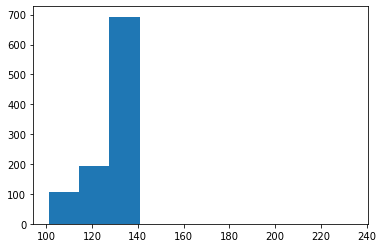

In [23]:
plt.hist(vc_sku)

In [24]:
np.min(vc_sku),np.max(vc_sku)

(101, 234)

## descriptive statistics

**`ord_rev`, `ord_qty`, `cnvrsn_rate` has negative values**

In [25]:
df_gt100.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,1.245870e+05,124587.000000,121828.000000,105748.000000,124563.000000,108085.000000,111319.000000,44005.000000,44005.000000,44005.000000
mean,1.292158e+04,83.663713,680.992202,180.463739,3114.358084,0.031209,0.068294,2.991524,0.484854,0.171254
std,6.124485e+04,318.781211,919.062641,107.769601,8392.660454,0.192078,0.208867,4.228691,1.042885,0.313800
min,-1.909576e+05,-683.000000,1.000000,-275.620000,0.000000,-3.000000,0.000000,1.000000,0.000000,0.000000
25%,2.977600e+02,2.000000,140.000000,99.990000,115.000000,0.010612,0.000000,1.000000,0.000000,0.000000
50%,1.979910e+03,13.000000,341.000000,159.990000,834.000000,0.020344,0.000000,2.000000,0.000000,0.000000
75%,9.072950e+03,57.000000,901.000000,239.990000,2951.000000,0.036757,0.015260,3.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,24047.000000,1429.460000,871072.000000,49.000000,1.000000,106.000000,30.000000,1.000000


In [26]:
NA_df_gt100 = dict()
cols = df_gt100.columns
for col in cols:
    NA_df_gt100[col] = sum(df_gt100[col].isna())

In [27]:
NA_df_gt100

{'asin': 0,
 'prdct_title': 0,
 'ord_rev': 0,
 'ord_qty': 0,
 'sale_rank': 2759,
 'avg_price': 18839,
 'gv': 24,
 'cnvrsn_rate': 16502,
 'rep_oos': 13268,
 'zinus_sku': 0,
 'collection': 0,
 'profile': 40814,
 'size': 17029,
 'rvw_cnt': 80582,
 'star12_cnt': 80582,
 'star12_ratio': 80582,
 'year_week': 0}

## drop negative values

In [28]:
rows_to_drop = (df_gt100.ord_rev < 0) | (df_gt100.ord_qty <0) | (df_gt100.cnvrsn_rate <0)
sum(rows_to_drop)

877

In [29]:
neg_idx = rows_to_drop[rows_to_drop].index

In [30]:
df_gt100.loc[neg_idx]

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,rvw_cnt,star12_cnt,star12_ratio,year_week
395,B079P6NBXZ,Zinus Gel Memory Foam 3 Inch Tri-Fold Comfort ...,-52.11,-1,202,52.11,0,NaN,0.0,AZ-TRI-3S,TRI,3 Inch,Single,<NA>,<NA>,NaN,2020-01-05
46386,B06WVXTGVH,Zinus 12 Inch Foam and Spring Mattress / Certi...,-1.72,0,237,NaN,488,0.000000,0.0,OLB-BNSM-12K,OLB BNSM,12 inch,King,<NA>,<NA>,NaN,2020-09-13
46435,B071CLRK9G,Zinus Van 16 Inch Metal Platform Bed Frame wit...,-275.62,1,70,-275.62,6552,0.000153,0.0,AZ-MPRC-16K,MPRC,14 Inch,King,8,1,0.125,2020-09-13
46556,B06XHTZ74K,ZINUS SmartBase Bed Skirt / 14 Inch Drop / For...,-45.57,-3,<NA>,15.19,0,NaN,NaN,OLB-EBS-14TXL,OLB EBS,14 Inch,Twin XL,1,1,1.000,2020-09-13
46561,B07KK7BQ1G,Zinus Deluxe Mid-Century Wood Platform Bed wit...,-270.47,-1,324,270.47,0,NaN,1.0,SWPBBHM-12Q,SWPBBHM,14 Inch,Queen,<NA>,<NA>,NaN,2020-09-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172871,B07B9LWFPG,ZINUS Moiz Deluxe Wood Platform Bed Frame / Wo...,-184.70,-1,450,184.70,0,NaN,NaN,OLB-RWPBB-14F,OLB RWPBB,14 Inch,Full,<NA>,<NA>,NaN,2022-06-12
173153,B07CYN5CCX,Zinus 6 Inch Mint Green Memory Foam Hybrid Spr...,-244.43,-1,<NA>,244.43,0,NaN,1.0,AZ-MGSM-6Q,MGSM,6 Inch,Queen,<NA>,<NA>,NaN,2022-06-12
173229,B006L7RTKU,ZINUS 8 Inch Quilted Pocket Spring Mattress / ...,-214.20,-1,159,214.20,5,-0.200000,0.0,SC-SMT-8Q,SMT,8 Inch,Queen,<NA>,<NA>,NaN,2022-06-12
173530,B07CQN7F7S,ZINUS Luke 59 Inch Black Metal Corner Desk / L...,-357.18,-1,826,357.18,94,-0.010638,0.0,OLB-LD-A59E,OLB LD,None,None,<NA>,<NA>,NaN,2022-06-12


In [31]:
df_gt100.drop(index=neg_idx,axis=0, inplace=True)

In [32]:
df_gt100.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,1.237100e+05,123710.000000,121037.000000,104932.000000,123687.000000,107617.000000,110463.000000,43826.000000,43826.000000,43826.000000
mean,1.301825e+04,84.280147,680.160356,180.323095,3134.437726,0.031658,0.065483,2.996144,0.485442,0.171162
std,6.144803e+04,319.817877,916.620435,107.629773,8418.069995,0.191773,0.202871,4.235332,1.044183,0.313586
min,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.136750e+02,2.000000,139.000000,99.990000,120.000000,0.010728,0.000000,1.000000,0.000000,0.000000
50%,2.023000e+03,13.000000,340.000000,159.921102,848.000000,0.020433,0.000000,2.000000,0.000000,0.000000
75%,9.189067e+03,57.000000,900.000000,239.990000,2976.000000,0.036903,0.015085,3.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,24047.000000,1429.460000,871072.000000,49.000000,1.000000,106.000000,30.000000,1.000000


In [33]:
len(df_gt100.zinus_sku.unique())

997

## Replacing NA

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rep_oos` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

### date range and filling

In [34]:
dt_rg = pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')
dt_rg.name='year_week'

In [35]:
df_gt100.columns

Index(['asin', 'prdct_title', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price',
       'gv', 'cnvrsn_rate', 'rep_oos', 'zinus_sku', 'collection', 'profile',
       'size', 'rvw_cnt', 'star12_cnt', 'star12_ratio', 'year_week'],
      dtype='object')

In [36]:
df_gt100.sort_index(inplace=True)

In [68]:
lag_features = ['sale_rank', 'avg_price', 'gv', 'cnvrsn_rate', 'rep_oos', 'rvw_cnt', 'star12_cnt', 'star12_ratio']

df_set_columns = ['year_week', 'ord_rev', 'ord_qty', 'zinus_sku', 'collection', 'profile', 'sale_rank_lag1',\
 'avg_price_lag1', 'gv_lag1', 'cnvrsn_rate_lag1', 'rep_oos_lag1', 'rvw_cnt_lag1', 'star12_cnt_lag1', 'star12_ratio_lag1']
df_set = pd.DataFrame(columns=df_set_columns)

for k,sku in enumerate(sku_gt_100):
    print('Working %d/%d...' % ((k+1),len(sku_gt_100)), end='\r')
    src_df = df_gt100[df_gt100.zinus_sku==sku].set_index('year_week')
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(src_df)
    
    # For meaningfull ffill(), need to fill '0' first row.
    tmp_df[:1] = tmp_df[:1].fillna(0)
    
    tmp_df['zinus_sku'] = np.repeat(src_df.zinus_sku.unique(),tmp_df.shape[0])
    tmp_df['collection'] = np.repeat(src_df.collection.unique(),tmp_df.shape[0])
    tmp_df['profile'] = np.repeat(src_df.profile.unique(),tmp_df.shape[0])
    
    # More than 128 samples should be treated
    tmp_df_m = tmp_df.resample('W-Sun').mean() 
    #lost_cols = list(set(tmp_df.columns)-set(tmp_df_m))
    lost_cols=['zinus_sku','collection','profile']
    
    tmp_df_m.reset_index(inplace=True)
    tmp_df.reset_index(inplace=True)
    tmp_df_m[lost_cols] = tmp_df[lost_cols]
    
    tmp_df_m[['ord_rev', 'ord_qty']] = \
            tmp_df_m[['ord_rev', 'ord_qty']].ffill()
    tmp_df_m[['sale_rank','avg_price', 'cnvrsn_rate']] = \
            tmp_df_m[['sale_rank', 'avg_price', 'cnvrsn_rate']].ffill()
    tmp_df_m[['gv','rep_oos', 'rvw_cnt','star12_cnt', 'star12_ratio']] = \
            tmp_df_m[['gv','rep_oos', 'rvw_cnt','star12_cnt', 'star12_ratio']].fillna(0)
    
    tmp_df_m_lagged = tmp_df_m[lag_features].shift(1)
    tmp_df_m_lagged.columns = [x+'_lag1' for x in lag_features]
    tmp_df_m_lagged.fillna(0,inplace=True) # Fill 0 in first row
    
    tmp_df_m.drop(lag_features,axis=1,inplace=True)
    tmp_df_m = pd.concat([tmp_df_m,tmp_df_m_lagged],axis=1)
    
    df_set = df_set.append(tmp_df_m)
    del tmp_df, tmp_df_m

In [70]:
df_gt100.shape

(123710, 17)

In [71]:
df_set.shape

(127616, 14)

In [72]:
df_set.zinus_sku.unique()

array(['OLB-SWPB-12T', 'SC-BTCM-8Q', 'SC-SPP-10SQ', 'SC-SMT-8TXL',
       'OLB-MGT-150F', 'OLB-BNSM-6F', 'AZ-SBF-07Q', 'AZ-HDBF-7T',
       'AZ-SBF-07CK', 'AZ-HDBF-7CK', 'AZ-SBF-07U', 'AZ-SBF-07T',
       'AZ-SBF-07F', 'AZ-SBF-07K', 'OLB-SBF-U2', 'OLB-ABS-7F',
       'OLB-ABS-7K', 'OLB-ABS-7T', 'OLB-ABS-7Q', 'AZ-HDBF-7U1',
       'AZ-HDBF-7U2', 'OLB-ABS-7TXL', 'OLB-ABS-7CK', 'OLB-SSBFH-7F',
       'OLB-SSBFH-7K', 'OLB-SSBFH-7T', 'FTTP-F', 'OLB-FGM-0600SQ',
       'FTTP-K', 'OLB-GTFM-6N', 'M-FMS-600F', 'M-FMS-600T',
       'OLB-BNSM-6SQ', 'M-FMS-600Q', 'OLB-GTFM-6F', 'OLB-GTFM-6K',
       'OLB-GTFM-6T', 'OLB-GTFM-6Q', 'EFPB-Q', 'OLB-GTFM-6SQ',
       'OLB-SSBF-7F', 'IRPF-6K', 'IRPF-6Q', 'OLB-FGM-0600F',
       'OLB-FGM-0600T', 'OLB-FGM-0600Q', 'OLB-MBBF-6F', 'OLB-MBBF-6K',
       'OLB-MBBF-6T', 'OLB-MBBF-6Q', 'OLB-SSBFH-7Q', 'OLB-SSBF-7Q',
       'OLB-SSBF-7T', 'OLB-GTFM-8Q', 'CSPB-T-Q', 'AZ-MGSM-8Q',
       'OLB-BNSM-8F', 'FHCP-Q', 'OLB-BNSM-8Q', 'OLB-BNSM-8SQ',
       'OLB-GTFM-8F', '

In [73]:
df_set[['zinus_sku','year_week']].groupby('zinus_sku').agg('count')

,year_week
zinus_sku,
ADB-14Q,128
ADB-14TXL,128
AZ-ASMP-10F,128
AZ-ASMP-10K,128
AZ-ASMP-10Q,128
...,...
ZU-TMTCCS-02T,128
ZU-TMTCCS-03F,128
ZU-TMTCCS-03K,128


# Modeling (interaction terms from GA2M)

Microsoft EBM package (https://interpret.ml/docs/ebm.html)

In [76]:
features = ['sale_rank_lag1', 'avg_price_lag1', 'gv_lag1', 'cnvrsn_rate_lag1',
       'rep_oos_lag1', 'rvw_cnt_lag1', 'star12_cnt_lag1', 'star12_ratio_lag1']

In [81]:
SKUs = df_set.zinus_sku.unique().tolist()

## OOV (Out of Sample Validation : Cross-Sectional) performance

In [88]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oov = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.zinus_sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Cross-sectional
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
    
    # Time-series like
    #tSize = 24 # approx. 6 month
    #X_train=X.iloc[:-tSize,]
    #X_test=X.iloc[-tSize:,]
    #y_train=y.iloc[:-tSize]
    #y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oov.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Price is a predictor?

In [195]:
price_imp = [x['avg_price_lag1'] for x in df_ebm_oov.imp95 if 'avg_price_lag1' in x.keys()]
price_imp

[0.09,
 0.182,
 0.152,
 0.142,
 0.149,
 0.194,
 0.094,
 0.097,
 0.085,
 0.091,
 0.159,
 0.137,
 0.102,
 0.11,
 0.097,
 0.124,
 0.101,
 0.172,
 0.071,
 0.126,
 0.149,
 0.115,
 0.102,
 0.157,
 0.095,
 0.23,
 0.134,
 0.091,
 0.152,
 0.084,
 0.11,
 0.118,
 0.111,
 0.158,
 0.167,
 0.228,
 0.104,
 0.078,
 0.149,
 0.12,
 0.199,
 0.205,
 0.127,
 0.151,
 0.081,
 0.097,
 0.097,
 0.123,
 0.171,
 0.165,
 0.131,
 0.109,
 0.176,
 0.111,
 0.093,
 0.203,
 0.116,
 0.204,
 0.077,
 0.196,
 0.184,
 0.233,
 0.077,
 0.045,
 0.104,
 0.064,
 0.121,
 0.185,
 0.147,
 0.189,
 0.082,
 0.134,
 0.06,
 0.216,
 0.24,
 0.163,
 0.222,
 0.118,
 0.219,
 0.123,
 0.13,
 0.166,
 0.112,
 0.076,
 0.066,
 0.126,
 0.156,
 0.23,
 0.172,
 0.107,
 0.098,
 0.148,
 0.133,
 0.295,
 0.168,
 0.205,
 0.129,
 0.207,
 0.121,
 0.1,
 0.129,
 0.171,
 0.121,
 0.108,
 0.061,
 0.172,
 0.049,
 0.224,
 0.135,
 0.087,
 0.111,
 0.149,
 0.171,
 0.153,
 0.16,
 0.154,
 0.126,
 0.108,
 0.121,
 0.248,
 0.144,
 0.121,
 0.089,
 0.165,
 0.145,
 0.238,
 0.0

### Most of the SKU has `avg_price` as a predictor

In [196]:
len(price_imp)

994

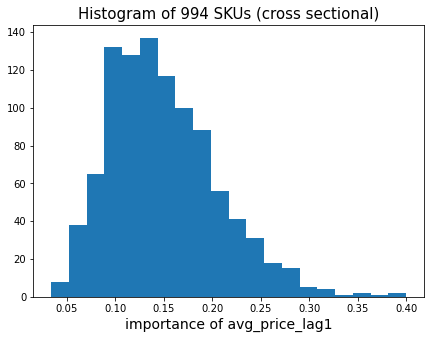

In [207]:
plt.figure(figsize=(7,5))
plt.hist(price_imp,bins=20)
plt.xlabel('importance of avg_price_lag1',fontsize=14)
plt.title('Histogram of 994 SKUs (cross sectional)',fontsize=15)
plt.show()

## R2 of in-sample & out-of-sample

In [114]:
df_ebm_oov[['r2_i','r2_o']]

,r2_i,r2_o
0,0.48,0.13
1,0.79,0.45
2,0.86,0.83
3,0.52,0.09
4,0.57,0.06
...,...,...
992,0.72,0.48
993,0.64,-0.03
994,0.49,0.22
995,0.96,0.76


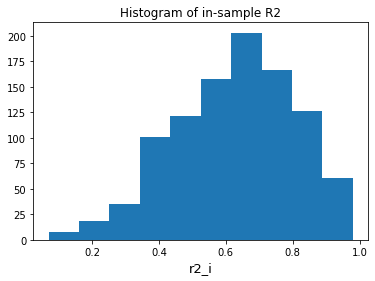

In [129]:
plt.hist(df_ebm_oov.r2_i)
plt.xlabel('r2_i',fontsize=13)
plt.title('Histogram of in-sample R2')
plt.show()

In [122]:
print('mean \t: ',df_ebm_oov.r2_i.mean().round(3), '\n',
      'var  \t: ',df_ebm_oov.r2_i.var().round(3), '\n')

mean 	:  0.627 
 var  	:  0.032 



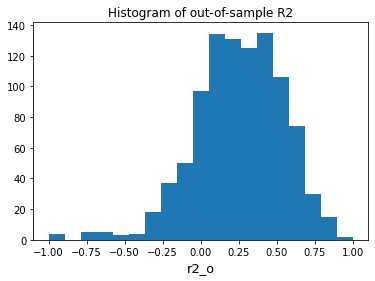

In [133]:
plt.hist(df_ebm_oov.r2_o,bins=np.linspace(-1,1,20))
plt.xlabel('r2_o',fontsize=13)
plt.title('Histogram of out-of-sample R2')
plt.show()

In [134]:
print('mean \t: ',df_ebm_oov.r2_o.mean().round(3), '\n',
      'var  \t: ',df_ebm_oov.r2_o.var().round(3), '\n')

mean 	:  0.186 
 var  	:  0.444 



## R2 diff

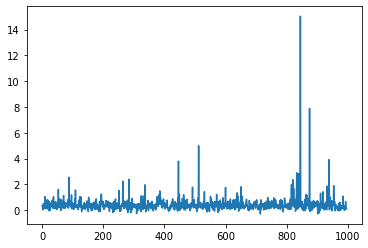

In [141]:
df_ebm_oov['r2_diff'] = df_ebm_oov.r2_i-df_ebm_oov.r2_o
df_ebm_oov.r2_diff.plot()
plt.show()

In [142]:
# SKUs with big negative R2
sum(df_ebm_oov.r2_o < 0)

200

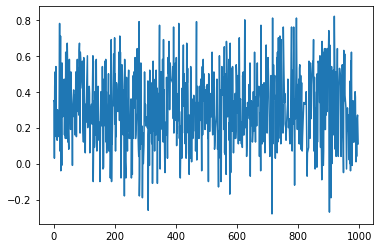

In [143]:
# Excluding that, but shows big difference
df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].plot()
plt.show()

In [144]:
df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff']

0      0.35
1      0.34
2      0.03
3      0.43
4      0.51
       ... 
991    0.04
992    0.24
994    0.27
995     0.2
996    0.11
Name: r2_diff, Length: 797, dtype: object

In [145]:
print('mean \t: ',df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.302 
 var  	:  0.04 



In [151]:
# About 11% of SKU have less than 10% diff
sum(np.abs(df_ebm_oov.r2_diff)<=0.1)

109

In [152]:
109/979

0.11133810010214505

In [153]:
skus_r2diff_lt_10 = df_ebm_oov[np.abs(df_ebm_oov.r2_diff)<=0.1].sku
skus_r2diff_lt_10

2        SC-SPP-10SQ
20       AZ-HDBF-7U2
23      OLB-SSBFH-7F
26            FTTP-F
49       OLB-MBBF-6Q
           ...      
969    ZU-TMTCCS-01T
971       PS-H2010BP
976       MSHBBT-12Q
989       MSHBBT-10F
991       MSHBBT-08F
Name: sku, Length: 109, dtype: object

### SKU with huge difference 

In [154]:
idx = np.argmax(df_ebm_oov[df_ebm_oov.r2_o < 0]['r2_diff'])
df_ebm_oov[df_ebm_oov.r2_o < 0].iloc[idx]

sku                                              ZU-TMTCCS-03F
rmse_i                                                 2308.16
mape_i                                                  108.37
r2_i                                                      0.73
rmse_o                                                 1484.29
mape_o                                                  347.64
r2_o                                                     -14.3
imp95        {'gv_lag1': 0.142, 'avg_price_lag1': 0.126, 'r...
ebm_model    ExplainableBoostingRegressor(feature_names=['s...
r2_diff                                                  15.03
Name: 845, dtype: object

In [155]:
df_set[df_set.zinus_sku=='ZU-TMTCCS-03F'].ord_rev

0         0.00
1         0.00
2         0.00
3         0.00
4        79.99
        ...   
123     242.37
124     501.53
125     475.93
126    1155.83
127     323.16
Name: ord_rev, Length: 128, dtype: float64

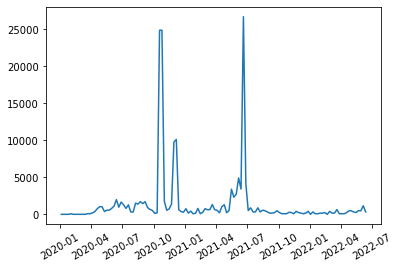

In [162]:
df_HugeDiff = df_set[df_set.zinus_sku=='ZU-TMTCCS-03F']
plt.plot(df_HugeDiff.year_week,df_HugeDiff.ord_rev)
plt.xticks(rotation=30)
plt.show()

In [163]:
sum(df_set[df_set.zinus_sku=='ZU-TMTCCS-03F'].ord_rev==0.0)

12

# OOVT (Out of Sample Validation : Time-aware) performance

In [100]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oovt = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

tSize = 24 # approx. 6 month
    
for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.zinus_sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Time-series like

    X_train=X.iloc[:-tSize,]
    X_test=X.iloc[-tSize:,]
    y_train=y.iloc[:-tSize]
    y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oovt.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

## Price is a predictor?

In [198]:
price_imp = [x['avg_price_lag1'] for x in df_ebm_oovt.imp95 if 'avg_price_lag1' in x.keys()]
price_imp

[0.096,
 0.172,
 0.131,
 0.089,
 0.128,
 0.212,
 0.103,
 0.106,
 0.064,
 0.106,
 0.217,
 0.134,
 0.123,
 0.099,
 0.1,
 0.127,
 0.095,
 0.097,
 0.083,
 0.152,
 0.103,
 0.099,
 0.129,
 0.16,
 0.143,
 0.187,
 0.211,
 0.061,
 0.104,
 0.061,
 0.142,
 0.121,
 0.1,
 0.196,
 0.129,
 0.236,
 0.102,
 0.104,
 0.162,
 0.163,
 0.14,
 0.274,
 0.15,
 0.102,
 0.13,
 0.104,
 0.156,
 0.135,
 0.209,
 0.184,
 0.116,
 0.142,
 0.136,
 0.097,
 0.122,
 0.169,
 0.152,
 0.196,
 0.079,
 0.173,
 0.131,
 0.158,
 0.089,
 0.076,
 0.106,
 0.076,
 0.147,
 0.174,
 0.153,
 0.221,
 0.097,
 0.107,
 0.12,
 0.163,
 0.249,
 0.151,
 0.219,
 0.069,
 0.163,
 0.104,
 0.117,
 0.152,
 0.119,
 0.131,
 0.073,
 0.099,
 0.2,
 0.218,
 0.128,
 0.085,
 0.096,
 0.146,
 0.125,
 0.24,
 0.134,
 0.194,
 0.162,
 0.16,
 0.099,
 0.091,
 0.113,
 0.234,
 0.089,
 0.095,
 0.055,
 0.151,
 0.034,
 0.22,
 0.149,
 0.094,
 0.105,
 0.111,
 0.106,
 0.135,
 0.191,
 0.115,
 0.145,
 0.084,
 0.092,
 0.179,
 0.098,
 0.098,
 0.129,
 0.176,
 0.175,
 0.235,
 0.189

### Most of the SKU has `avg_price` as a predictor

In [199]:
len(price_imp)

989

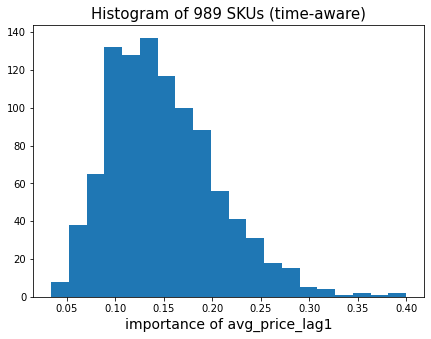

In [208]:
plt.figure(figsize=(7,5))
plt.hist(price_imp,bins=20)
plt.xlabel('importance of avg_price_lag1',fontsize=14)
plt.title('Histogram of 989 SKUs (time-aware)',fontsize=15)
plt.show()

## R2 of in-sample & out-of-sample

In [164]:
df_ebm_oovt[['r2_i','r2_o']]

,r2_i,r2_o
0,0.49,-0.1
1,0.74,0.2
2,0.91,0.0
3,0.44,-0.24
4,0.24,-4.36
...,...,...
992,0.9,-0.18
993,0.62,-0.04
994,0.46,-0.47
995,0.94,0.0


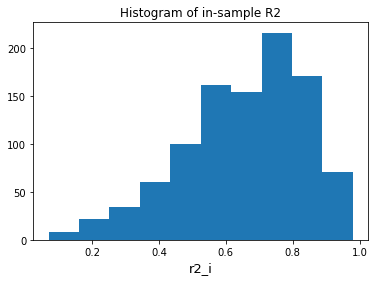

In [165]:
plt.hist(df_ebm_oovt.r2_i)
plt.xlabel('r2_i',fontsize=13)
plt.title('Histogram of in-sample R2')
plt.show()

In [166]:
print('mean \t: ',df_ebm_oovt.r2_i.mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt.r2_i.var().round(3), '\n')

mean 	:  0.654 
 var  	:  0.032 



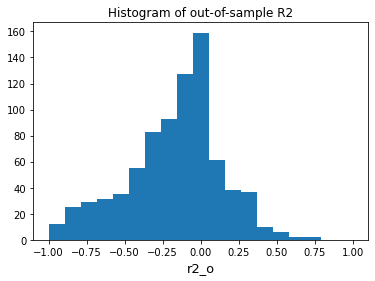

In [167]:
plt.hist(df_ebm_oovt.r2_o,bins=np.linspace(-1,1,20))
plt.xlabel('r2_o',fontsize=13)
plt.title('Histogram of out-of-sample R2')
plt.show()

In [168]:
print('mean \t: ',df_ebm_oovt.r2_o.mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt.r2_o.var().round(3), '\n')

mean 	:  -68.956 
 var  	:  1436830.19 



## R2 diff

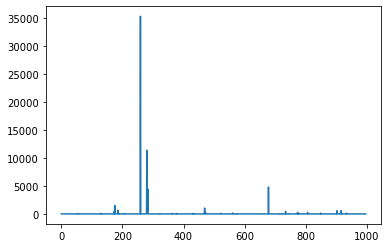

In [170]:
df_ebm_oovt['r2_diff'] = df_ebm_oovt.r2_i-df_ebm_oovt.r2_o
df_ebm_oovt.r2_diff.plot()
plt.show()

In [172]:
# SKUs with big negative R2
sum(df_ebm_oovt.r2_o <= 0)

798

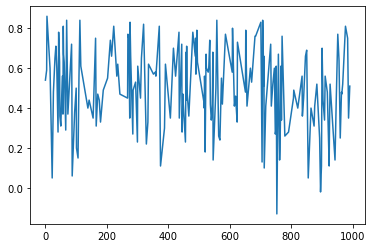

In [173]:
# Excluding that, but shows big difference
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].plot()
plt.show()

In [174]:
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff']

1      0.54
5      0.59
6      0.86
11     0.73
16      0.6
       ... 
967    0.52
976    0.81
983    0.75
986    0.35
990    0.51
Name: r2_diff, Length: 199, dtype: object

In [175]:
print('mean \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.5 
 var  	:  0.042 



In [181]:
# About 0.6% of SKU have less than 10% diff
sum(np.abs(df_ebm_oovt.r2_diff)<0.1)

6

In [182]:
6/997

0.006018054162487462

In [183]:
skus_Tr2diff_lt_10 = df_ebm_oovt[np.abs(df_ebm_oovt.r2_diff)<0.1].sku
skus_Tr2diff_lt_10

23     OLB-SSBFH-7F
88      AZ-HBBS-75Q
712       AZ-PD1T-K
855      FPWSBA-10F
895        IRPFG-6F
965      FRBX-4NV-K
Name: sku, dtype: object

### SKU with huge difference 

In [185]:
idx = np.argmax(df_ebm_oovt[df_ebm_oovt.r2_o < 0]['r2_diff'])
df_ebm_oovt[df_ebm_oovt.r2_o < 0].iloc[idx]

sku                                                OLB-QLBKB-T
rmse_i                                                 1263.13
mape_i                                                   72.35
r2_i                                                      0.84
rmse_o                                                  1619.2
mape_o                                                 4716.67
r2_o                                                 -35279.74
imp95        {'gv_lag1': 0.173, 'cnvrsn_rate_lag1': 0.148, ...
ebm_model    ExplainableBoostingRegressor(feature_names=['s...
r2_diff                                               35280.58
Name: 259, dtype: object

In [186]:
df_set[df_set.zinus_sku=='OLB-QLBKB-T'].ord_rev

0      5205.80
1      5607.20
2      5846.58
3      3758.90
4      5031.79
        ...   
123       0.00
124       0.00
125       0.00
126       0.00
127       0.00
Name: ord_rev, Length: 128, dtype: float64

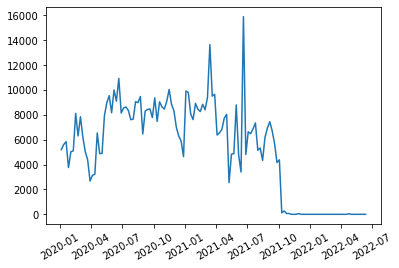

In [190]:
df_HugeDiff = df_set[df_set.zinus_sku=='OLB-QLBKB-T']
plt.plot(df_HugeDiff.year_week,df_HugeDiff.ord_rev)
plt.xticks(rotation=30)
plt.show()

In [191]:
sum(df_set[df_set.zinus_sku=='OLB-QLBKB-T'].ord_rev==0.0)

30

# Save performance files

In [189]:
df_ebm_oov.to_pickle('df_ebm_oov_lag.pickle')
df_ebm_oovt.to_pickle('df_ebm.oovt_lag.pickle')